To begin, import wfdb library for data read and plot. This section reads a WFDB record named '100' and return a Record or MultiRecord object. A record object wraps both signal data and metadata from .dat and .hea files.
The wfdb_plot command does a quick subplot of length-specified individual channels of a WFDB record and/or annotation.

### `record` attributes:
- `p_signal` (and by default physical=True) import converted physical signal in mV, i.e. import as NumPy array of the preprocessed signals (scaled to physical units, mV)
- `d_signal` AND `physical = False` import raw adc codes
- `sig_len` signal sample length (e.g. 65000)
- `sig_name` signal names (e.g. MLII, V5)
- `units` signal units (e.g. mV)
- `adc_gain` ADC gain ratio (e.g. 200)
- `baseline` ADC baseline code value (e.g. 1024)


### `annotation` attributes
- `sample` list of sample indicies (e.g. [18 77 ...])
- `symbol` list of eveny types (e.g. `'N'` for normal beat, `'V'` for Premature ventricular contraction, `'L'` for Left bundle branch block)
- `chan` channel number where annotation was recorded (e.g. [0 0 0 ...])

In the dataset, recorded ECG data has 2 ECG channels 
| Channel   | Lead | Placement | Captures |
|----------|----------|----------|----------|
| 1 - MLII  | Modified Lead II | Right shoulder -> left leg | Strong P wave and QRS visibility, common for arrythmia detection | 
| 2 - V5    | V5  | 5th intercostal space | Left ventricular activity, ST changes |

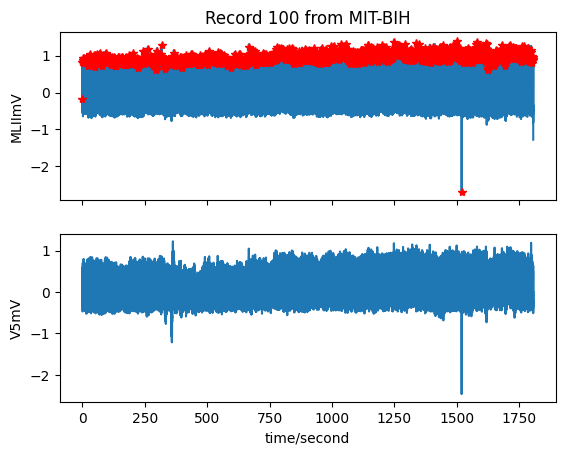

Sample rate: 360
Raw ADC Data shape: (650000, 2)
Total record length is 0.50 hr
Signal names: ['MLII', 'V5']
Units: ['mV', 'mV']
ADC Gain: [200.0, 200.0]
Baseline: [1024, 1024]


In [1]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, lfilter, find_peaks
# ##########################
# Examine recording
# Example dataset used is '100'
# 100.dat = data with MLII and V5 leads, 100.hea, 100.atr = annotations
# ##########################

## Option 1 - Host data in local repo, in a 'data' folder
record = wfdb.rdrecord('../data/100')  # Default imports converted physical signal (mV)
header = wfdb.rdheader('../data/100')
annotation = wfdb.rdann('../data/100', 'atr') 
## Option 2 - Stream data from Physionet (Internet access needed)
# record = wfdb.rdrecord('100', sampto=1000, pn_dir='mitdb')  # pn_dir is the option used to stream data from Physionet.
# header = wfdb.rdheader('data/100', pn_dir='mitdb')
# annotation = wfdb.rdann('100', 'atr', sampto=1000, pn_dir='mitdb')

# EZ subplot ECG excerpt for quick examination
wfdb.plot_wfdb(record=record, annotation=annotation, title='Record 100 from MIT-BIH')

# Basic Record object attributes
print(f"Sample rate: {record.fs}")
record_adc = wfdb.rdrecord('../data/100', physical=False)  # Make physical=False to import raw ADC data (codes)
print(f"Raw ADC Data shape: {record_adc.d_signal.shape}")
print(f"Total record length is { record.sig_len / record.fs / 3600:.2f} hr")
print(f"Signal names: {record.sig_name}")
print(f"Units: {record.units}")
print(f"ADC Gain: {record.adc_gain}")
print(f"Baseline: {record.baseline}")

This block examines a section of converted .p_signal, and raw .d_signal. Since p_signal are conversion-ready signal, we want to examine whether the math checks out. So on the raw ADC data d_signal, we perform baseline removal and scaling to check accuracy of wfdb library converted physical values. To scale ADC raw codes to physical value in mV, perform `(adc_code[i] - baseline)/adc_gain`

length of sig is 3600, length of time is 3600


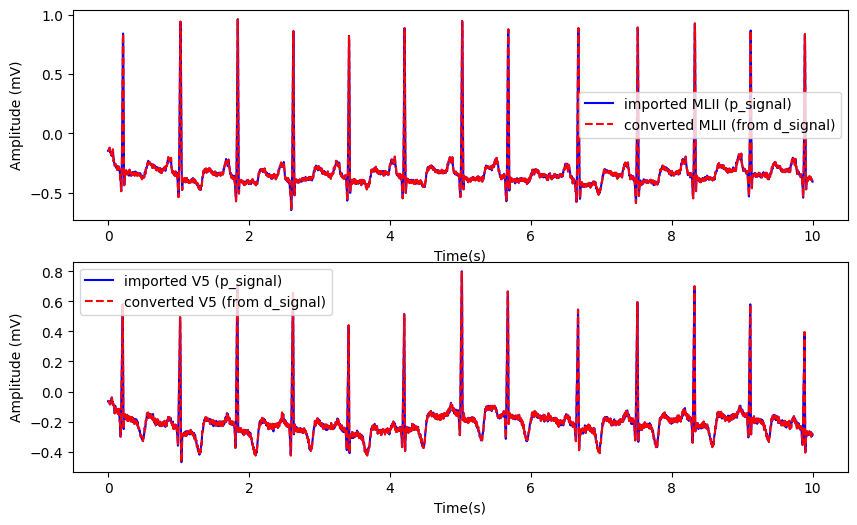

In [2]:
# ##########################
# Examine futher the imported physical signals
# ##########################
signal= record.p_signal  # Data col0=MLII
signal_MLII = signal[:,0]
signal_V5 = signal[:,1]   # Data col1=V5
raw_adc = record_adc.d_signal
raw_adc_MLII = raw_adc[:,0]
raw_adc_V5 = raw_adc[:,1]

conv_signal_MLII = (raw_adc_MLII - record.baseline[0])/record.adc_gain[0]
conv_signal_V5 = (raw_adc_V5 - record.baseline[1])/record.adc_gain[1]

def timeSeries_subplot_labels(ax_idx):
    ax_idx.set_xlabel('Time(s)')
    ax_idx.set_ylabel('Amplitude (mV)')
    ax_idx.legend()

fig, ax = plt.subplots(2, 1, figsize=(10, 6))
sig_length = record.fs * 10 # plotting 10s of signals
time = np.arange(0, sig_length)/record.fs
print(f"length of sig is {sig_length}, length of time is {len(time)}")

ax[0].plot(time, signal_MLII[:sig_length], color='blue',label='imported MLII (p_signal)')
ax[0].plot(time, conv_signal_MLII[:sig_length], color='red', ls='dashed',label='converted MLII (from d_signal)')
timeSeries_subplot_labels(ax[0])
ax[1].plot(time, signal_V5[:sig_length], color='blue',label='imported V5 (p_signal)')
ax[1].plot(time, conv_signal_V5[:sig_length], color='red', ls='dashed',label='converted V5 (from d_signal)')
timeSeries_subplot_labels(ax[1])

Pan-Tompkins Algorithm for Pre-processing [link] (https://en.wikipedia.org/wiki/Pan%E2%80%93Tompkins_algorithm)
1. Bandpass filtering, bandwidth 5-15Hz. Maximize QRS contribute, reduce muscle noise, baseline wander, powerline interference and P/T-wave freq contents.
2. Derivative filtering. Provide slope information of QRS complex. y[nT] = 1/8T * [-x(n-2) - 2x(n-1) + 2x(n+1) + x(n+2)], i.e. 5-point derivative filter coefficients are [-2 -1 - 1 2] with a gain of 1/8T. T is sample period (1/fs), which can be dropped often, just 1/8 or 0.1
3. Squaring to enhance dominant peaks (QRSs)
4. Moving average, window length 150ms. Essentially it is a filter with same coefficients equal to 1/window_len.
5. Find fiducial marks as candidate peaks with simple peak detection library. Rules: signal changes direction, 200ms lockout time
6. Validate candidate peaks for final QRS peaks

Now that we have integrated signal peaks validated, it's time to move on to heart rate detection. The equation is
HR (BPM) = 60 / RR (s) which means given adjacent R peaks happens in RR (s), or 1 beat per RR second, then for 60s the total beat is 60 / RR (BPM).

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

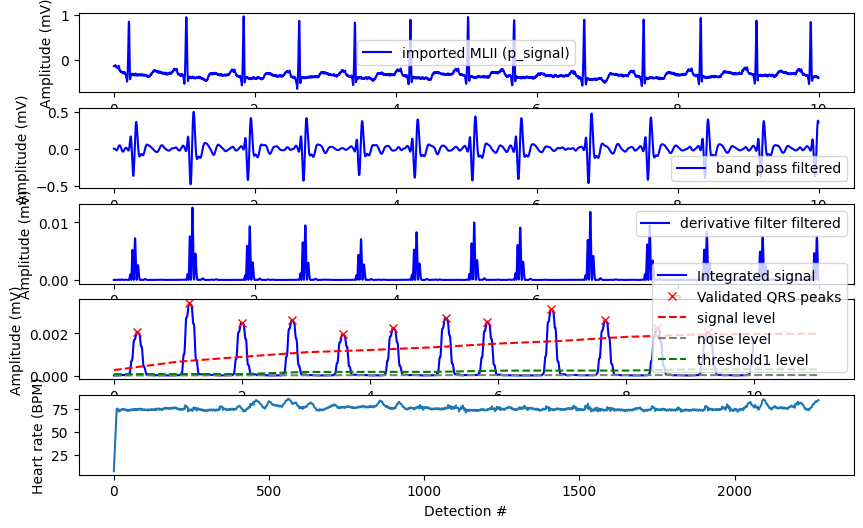

In [3]:
# ##########################
# QRS complex detection and heart rate estimation
# ##########################

# Pan-Tompkins algorithm for pre-processing
# Step 1 - Bandpass filter
bpf_lo = 5
bpf_hi = 15
fs = record.fs
b1, a1 = butter(4, [bpf_lo / (record.fs / 2), bpf_hi / (record.fs / 2)], 'bandpass') # butterworth, 4th order, bandpass filter
signal_MLII_bpf_filtered = lfilter(b1, a1, signal_MLII)
# Step 2 - Derivative filter
b2 = np.array([-1, -2, 0, 1, 2]) / 8    # In practical application, can drop T since slope matters more, not true gain
a2 = 1                                  # No feedback
signal_MLII_deriv_filtered = lfilter(b2, a2, signal_MLII_bpf_filtered)
# Step 3 - Squaring
signal_MLII_deriv_filtered = signal_MLII_deriv_filtered**2
# Step 4 - Moving average 
window_len = int(150e-3 * fs)           # 150ms window
b3 = np.ones(window_len)/window_len     # Moving average filter coefficients are 1/win_len
a3 = 1                                  # No feedback
signal_MLII_integrated = lfilter(b3, a3, signal_MLII_deriv_filtered)
# Step 5 - Candidate peaks detection
lockout_samples = int(200e-3 * fs)           # no peak can be detected in the next 200 ms
peaks_candidate, _ = find_peaks(signal_MLII_integrated, distance=lockout_samples)
# Step 6 - Validate QRS peaks from candidates
signal_level = 0.0  # Initialize running estimate of signal level (discrete, tracking candidate peaks), or signal peak level
noise_level = 0.0   # Initialize running estimate of noise level
threshold1 = 0.0    # Initial threshold
threshold2 = 0.0    # Backup threshold, lower, for missed QRS peak validation

peaks_qrs = []
signal_lvl = []
noise_lvl = []
threshold_lvl = []

for i in peaks_candidate:
    peak_magnitude = signal_MLII_integrated[i]

    if peak_magnitude > threshold1:
        # Detected as QRS, peak validated
        peaks_qrs.append(i)
        signal_level = 0.125 * peak_magnitude + 0.875 * signal_level
        signal_lvl.append(signal_level)
    else:
        noise_level = 0.125 * peak_magnitude + 0.875 * noise_level
        noise_lvl.append(noise_level)
    
    # Update threshold
    threshold1 = noise_level + 0.25 * (signal_level - noise_level)
    threshold2 = 0.5 * threshold1
    threshold_lvl.append(threshold1)

peaks_qrs = np.array(peaks_qrs)
peaks_qrs_sec = peaks_qrs[peaks_qrs <= sig_length]
# peaks_qrs_sec = [i for i in peaks_qrs if i <= sig_length]     # works when peaks_qrs is a list, not numpy array

# Heart rate estimation
RR_interval = np.diff(peaks_qrs)    # Peak indicies difference are sampes quantifying intervals between adjacent RR-intervals
HR_est = 60 / (RR_interval / fs)
# Apply a moving average to HR estimation to smooth results
window_len = 10           # 150ms window
b4 = np.ones(window_len)/window_len     # Moving average filter coefficients are 1/win_len
a4 = 1                                  # No feedback
HR_est_smoothed = lfilter(b4, a4, HR_est)

# Plotting pre-processed signals and heart rate
fig, ax = plt.subplots(5, 1, figsize=(10, 6))
ax[0].plot(time, signal_MLII[:sig_length], color='blue',label='imported MLII (p_signal)')
timeSeries_subplot_labels(ax[0])
ax[1].plot(time, signal_MLII_bpf_filtered[:sig_length], color='blue',label='band pass filtered')
timeSeries_subplot_labels(ax[1])
ax[2].plot(time, signal_MLII_deriv_filtered[:sig_length], color='blue',label='derivative filter filtered')
timeSeries_subplot_labels(ax[2])
ax[3].plot(time, signal_MLII_integrated[:sig_length], color='blue',label='Integrated signal')
ax[3].plot(time[peaks_qrs_sec], signal_MLII_integrated[peaks_qrs_sec], "x", color='red', label='Validated QRS peaks')
ax[3].plot(signal_lvl[:len(peaks_qrs_sec)], linestyle='dashed', color='red', label='signal level')
ax[3].plot(noise_lvl[:len(peaks_qrs_sec)], linestyle='dashed', color='grey', label='noise level')
ax[3].plot(threshold_lvl[:len(peaks_qrs_sec)], linestyle='dashed', color='green', label='threshold1 level')
timeSeries_subplot_labels(ax[3])
ax[4].plot(HR_est_smoothed, label='HR Estimation')
ax[4].set_xlabel('Detection #')
ax[4].set_ylabel('Heart rate (BPM)')
plt.tight_layout

Compare detected QRS peaks against original record annotation. 
- Top graph: original ECG MLII lead signal and annotation peaks (annotation.sample)
- Bottom graph: integrated ECG signal after filering, and detected QRS peaks
We notice there's a delay / shift from the processed signal, this is mainly due to the filters (bpf, derivative) used introducing group delay. They are basically due to filter doesn't respond instantly to input changes (especially those depending on past inputs), a few samples delays (lag behind) to all signal are common.

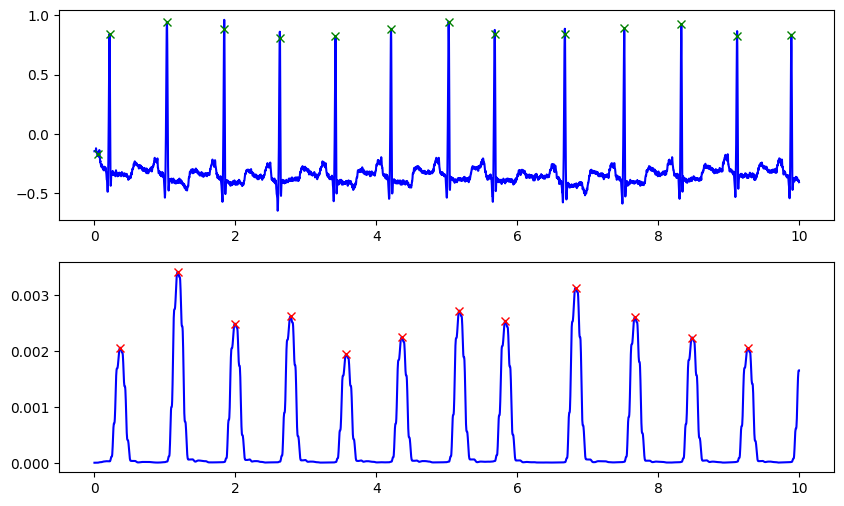

In [4]:
# Compare original ECG signal and annotation against integrated signal and detected QRS peaks
annotation_markers_sec = annotation.sample[annotation.sample <= sig_length]
fig, ax = plt.subplots(2, 1, figsize=(10, 6))
ax[0].plot(time, signal_MLII[:sig_length], color='blue',label='imported MLII (p_signal)')
ax[0].plot(time[annotation_markers_sec], signal_MLII[annotation_markers_sec], "x", color='green')
ax[1].plot(time, signal_MLII_integrated[:sig_length], color='blue',label='Integrated signal')
ax[1].plot(time[peaks_qrs_sec], signal_MLII_integrated[peaks_qrs_sec], "x", color='red', label='Validated QRS peaks')